# Portfolio Part 3 - Analysis of Mobile Price Data (2024 S1)

In this Portfolio task, you will work on a new dataset named 'Mobile Price Data', it contains numerous details about mobile phone hardware, specifications, and prices. Your main task is to train classification models to predict **mobile phone prices** ('price range' in the dataset)and evaluate the strengths and weaknesses of these models.

Here's the explanation of each column:

|Column|Meaning|
|:-----:|:-----:|
|battery power|Total energy a battery can store in one time measured in mAh|
|blue|Has bluetooth or not|
|clock speed|speed at which microprocessor executes instructions|
|dual sim|Has dual sim support or not|
|fc|Front Camera mega pixels|
|four g|Has 4G or not|
|int memory|Internal Memory in Gigabytes|
|m dep|Mobile Depth in cm|
|mobile wt|Weight of mobile phone|
|n cores|Number of cores of processor|
|pc|Primary Camera mega pixels|
|px height|Pixel Resolution Height|
|px width|Pixel Resolution Width|
|ram|Random Access Memory in Mega Bytes|
|sc h|Screen Height of mobile in cm|
|sc w|Screen Width of mobile in cm|
|talk time|longest time that a single battery charge will last when you are|
|three g|Has 3G or not|
|touch screen|Has touch screen or not|
|wifi|Has wifi or not|
|price range|This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost)|

Blue, dual sim, four g, three g, touch screen, and wifi are all binary attributes, 0 for not and 1 for yes.

Your high level goal in this notebook is to build and evaluate predictive models for 'price range' from other available features. More specifically, you need to **complete the following major steps**:

1. ***Explore the data*** and ***clean the data if necessary***. For example, remove abnormal instanaces and replace missing values.

2. ***Study the correlation*** between 'price range' with other features. And ***select the variables*** that you think are helpful for predicting the price range. We do not limit the number of variables.

3. ***Split the dataset*** (Trainging set : Test set = 8 : 2)

4. ***Train a logistic regression model*** to predict 'price range' based on the selected features (from the second step). ***Calculate the accuracy*** of your model. (You are required to report the accuracy from both training set and test set.) ***Explain your model and evaluate its performance*** (Is the model performing well? If yes, what factors might be contributing to the good performance of your model? If not, how can improvements be made?).

5. ***Train a KNN model*** to predict 'price range' based on the selected features (you can use the features selected from the second step and set K with an ad-hoc manner in this step. ***Calculate the accuracy*** of your model. (You are required to report the accuracy from both training set and test set.)

6. ***Tune the hyper-parameter K*** in KNN (Hints: GridsearchCV), ***visualize the results***, and ***explain*** how K influences the prediction performance.

  Hints for visualization: You can use line chart to visualize K and mean accuracy scores on test set.

Note 1: In this assignment, we no longer provide specific guidance and templates for each sub task. You should learn how to properly comment your notebook by yourself to make your notebook file readable.

Note 2: You will not being evaluated on the accuracy of the model but on the process that you use to generate it and your explanation.

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
ds = '/Users/irfanakram/Documents/GitHub/Irfan6200/Portfolio Submission COMP6200/portfolio-part-3-IrfanA13/Mobile_Price_Data.csv'

## Question 1: 


In [40]:
#Creating a dataframe from the given dataset
data = pd.read_csv('Mobile_Price_Data.csv')
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7.0,0.6,188,2,...,20,756.0,2549.0,9,7,19,0.0,0,1,1
1,1021,1,0.5,1,0,1,53.0,0.7,136,3,...,905,1988.0,2631.0,17,3,7,1.0,1,0,2
2,563,1,0.5,1,2,1,41.0,0.9,145,5,...,1263,1716.0,2603.0,11,2,9,1.0,1,0,2
3,615,1,2.5,0,0,0,10.0,0.8,131,6,...,1216,1786.0,2769.0,16,8,11,1.0,0,0,2
4,1821,1,1.2,0,13,1,44.0,0.6,141,2,...,1208,1212.0,1411.0,8,2,15,1.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2.0,0.8,106,6,...,1222,1890.0,668.0,13,4,19,1.0,1,0,0
1996,1965,1,2.6,1,0,0,39.0,0.2,187,4,...,915,1965.0,2032.0,11,10,16,1.0,1,1,2
1997,1911,0,0.9,1,1,1,36.0,0.7,108,8,...,868,1632.0,3057.0,9,1,5,1.0,1,0,3
1998,1512,0,0.9,0,4,1,46.0,0.1,145,5,...,336,670.0,869.0,18,10,19,1.0,1,1,0


In [41]:
#Checking info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1995 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  1995 non-null   int64  
 1   blue           1995 non-null   int64  
 2   clock_speed    1995 non-null   float64
 3   dual_sim       1995 non-null   int64  
 4   fc             1995 non-null   int64  
 5   four_g         1995 non-null   int64  
 6   int_memory     1995 non-null   float64
 7   m_dep          1995 non-null   float64
 8   mobile_wt      1995 non-null   int64  
 9   n_cores        1995 non-null   int64  
 10  pc             1995 non-null   int64  
 11  px_height      1995 non-null   int64  
 12  px_width       1995 non-null   float64
 13  ram            1995 non-null   float64
 14  sc_h           1995 non-null   int64  
 15  sc_w           1995 non-null   int64  
 16  talk_time      1995 non-null   int64  
 17  three_g        1995 non-null   float64
 18  touch_screen 

In [42]:
#Checking for null values
print(df.isnull().sum())

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


In [43]:
# Remove rows with missing values
df = df.dropna()
df.shape

(1995, 21)

In [44]:
#checking again for null values
print(df.isnull().sum())

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


## Question 2:

In [45]:
#Checking for correlation between price_tange and other features
correlations = df.corr().loc["price_range"]
correlations

battery_power    0.202652
blue             0.020846
clock_speed     -0.006926
dual_sim         0.018153
fc               0.019327
four_g           0.014572
int_memory       0.043861
m_dep            0.000776
mobile_wt       -0.028663
n_cores          0.003573
pc               0.031831
px_height        0.147946
px_width         0.164763
ram              0.917131
sc_h             0.023067
sc_w             0.037330
talk_time        0.022085
three_g          0.023771
touch_screen    -0.031155
wifi             0.020394
price_range      1.000000
Name: price_range, dtype: float64

In [46]:
#Sorting the correlations
correlations.sort_values()

touch_screen    -0.031155
mobile_wt       -0.028663
clock_speed     -0.006926
m_dep            0.000776
n_cores          0.003573
four_g           0.014572
dual_sim         0.018153
fc               0.019327
wifi             0.020394
blue             0.020846
talk_time        0.022085
sc_h             0.023067
three_g          0.023771
pc               0.031831
sc_w             0.037330
int_memory       0.043861
px_height        0.147946
px_width         0.164763
battery_power    0.202652
ram              0.917131
price_range      1.000000
Name: price_range, dtype: float64


From the analysis we take 3 features which are the most correlated: ram, battery_power and px_width. From the given values we see that all the selected features are positively correlated and ram is the most positively correlated which is close to one.

## Question 3:

In [47]:
#Taking the neccesary features for test train split
parameters = ['ram','battery_power','px_width','price_range']
correlated_data = df[parameters]
correlated_data

,ram,battery_power,px_width,price_range
0,2549.0,842,756.0,1
1,2631.0,1021,1988.0,2
2,2603.0,563,1716.0,2
3,2769.0,615,1786.0,2
4,1411.0,1821,1212.0,1
...,...,...,...,...
1995,668.0,794,1890.0,0
1996,2032.0,1965,1965.0,2
1997,3057.0,1911,1632.0,3
1998,869.0,1512,670.0,0


In [48]:
#Splitting the data into training and test sets
X = correlated_data.iloc[:, :3]
y = correlated_data['price_range']


X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
#Checking the shape of test and training data
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1596, 3)
y_train shape: (1596,)
X_test shape: (399, 3)
y_test shape: (399,)


## Question 4:

In [50]:
# Training the data using Logistic Regression
loReg = LogisticRegression(max_iter=5000)
loReg.fit(X_train,y_train)

LogisticRegression(max_iter=5000)

In [51]:
# the accuracy scores for both training and test data


test_accuracy = loReg.score(X_test, y_test)
train_accuracy = loReg.score(X_train, y_train)


print("Logistic Regression Test Data accuracy score", test_accuracy)
print("Logistic Regression Train Data accuracy score", train_accuracy)

Logistic Regression Test Data accuracy score 0.9072681704260651
Logistic Regression Train Data accuracy score 0.893483709273183


Explanation why good model: 

From both the test and train data score we see that both have have around 90%. Furthermore, as the selected variables for training the dataset have a good correlation with price range we get a good score on the Logistic regression model.



## Question 5:

In [52]:
# Training the data using KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [53]:
# the accuracy scores for both training and test data


test_accuracy = knn.score(X_test, y_test)
train_accuracy = knn.score(X_train, y_train)


print("KNN Test Data accuracy score", test_accuracy)
print("KNN Train Data accuracy score", train_accuracy)

KNN Test Data accuracy score 0.8796992481203008
KNN Train Data accuracy score 0.9179197994987469


## Question 6:

In [54]:
# Define search space for parameters
parameter_grid = {'n_neighbors': range(1, 50)}

In [55]:
# New KNN Classifier
knn_clf = KNeighborsClassifier()
clf = GridSearchCV(knn_clf, parameter_grid, scoring='accuracy', cv=10)
clf.fit(X, y)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 50)}, scoring='accuracy')

In [56]:
#Printing the best K value and the accuracy for that K value

print("Best K:", clf.best_params_['n_neighbors'])
print("Best Model Accuracy:", clf.best_score_)

Best K: 15
Best Model Accuracy: 0.8957412060301507


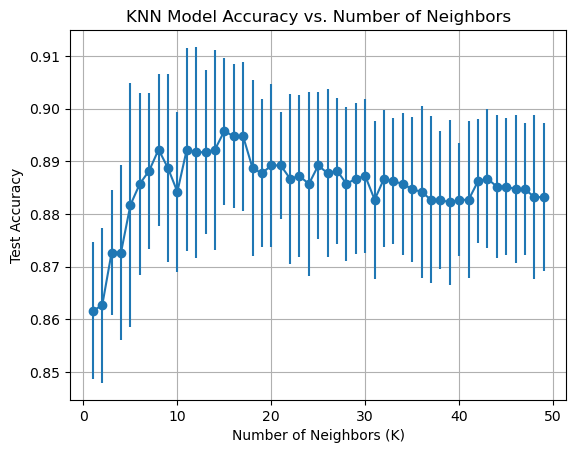

In [57]:
means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
params = clf.cv_results_['param_n_neighbors']

# Plotting the result 
plt.errorbar(params, means, stds, linestyle='-', marker='o')
plt.title('KNN Model Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

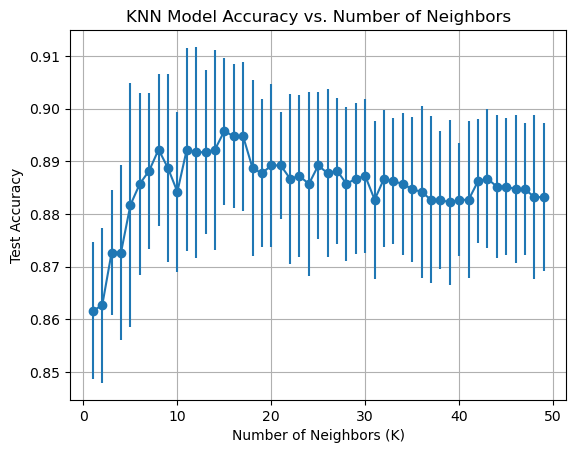

In [58]:
means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
params = clf.cv_results_['param_n_neighbors']

# Plotting the result 
plt.errorbar(params, means, stds, linestyle='-', marker='o')
plt.title('KNN Model Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

Depending on the K value, the model may be optimal. If we have a K value that is low it can lead to overfitting.Even though overfitting can lead to high training accuracy. But in case of test data the score would be low. On the other hand, if the K value is high it leads to underfitting. Hence, becomes less sensitive to the specific characteristics of the neighbors and leads to a overall low accuracy. An optimal K value is the middle ground of the two. It should be large enough to catch the significant patterns in the data, but not too huge that it becomes insensitive to local variation. 